# UMAP Trait Explorer

Compute a 2-D UMAP of the DNABERT-2 embeddings and colour each point by a phenotype value.
Continuous traits use a diverging colormap; categorical traits use a discrete palette.
Missing values are shown in light grey.

Sections:
1. Load & align data
2. Compute UMAP (once, reused for all panels)
3. Featured traits — 6-panel figure for the key agronomic traits
4. Full grid — every trait in a single figure

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import umap

EMB_PATH   = Path("/home/andrew.dickson/svar/embeddings/sativas413_embeddings.pt")
PHENO_PATH = Path("/home/andrew.dickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load & align

In [2]:
data        = torch.load(EMB_PATH, map_location="cpu", weights_only=True)
embeddings  = data["embeddings"].float().numpy()
emb_samples = data["sample_ids"]

pheno_raw  = pd.read_csv(PHENO_PATH, sep="\t")
TRAIT_COLS = [c for c in pheno_raw.columns if c not in ("HybID", "NSFTVID")]

emb_nsftvid   = [int(s.rsplit("_", 1)[-1]) for s in emb_samples]
emb_id_to_idx = {nid: i for i, nid in enumerate(emb_nsftvid)}
pheno_raw["NSFTVID"] = pheno_raw["NSFTVID"].astype(int)
pheno_matched = (pheno_raw[pheno_raw["NSFTVID"].isin(emb_id_to_idx)]
                 .copy().reset_index(drop=True))

emb_row_order = [emb_id_to_idx[nid] for nid in pheno_matched["NSFTVID"]]
X = StandardScaler().fit_transform(embeddings[emb_row_order])

# Raw phenotype values (unscaled) — better for visual interpretation
Y = pheno_matched[TRAIT_COLS].values.astype(float)

print(f"Samples: {X.shape[0]}   Traits: {len(TRAIT_COLS)}")

Samples: 383   Traits: 36


## 2. Compute UMAP

SVD to 20 components first (captures 99 %+ of variance), then UMAP.
Computed once here and reused for all trait panels below.

In [13]:
svd    = TruncatedSVD(n_components=20, random_state=42)
X_svd  = svd.fit_transform(X)

print(f"SVD cumulative variance (20 components): {svd.explained_variance_ratio_.sum():.3f}")
print(f"  PC1: {svd.explained_variance_ratio_[0]:.3f}  "
      f"PC2: {svd.explained_variance_ratio_[1]:.3f}")

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.01)
coords  = reducer.fit_transform(X_svd)
print(f"UMAP done: {coords.shape}")

SVD cumulative variance (20 components): 0.886
  PC1: 0.409  PC2: 0.122


/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (383, 2)


## 3. Plotting helper

In [14]:
# Traits with ≤12 unique values treated as categorical
CAT_TRAITS = {t for t in TRAIT_COLS
              if pheno_matched[t].dropna().nunique() <= 12}

def plot_umap_trait(ax, trait, coords, pheno_df, trait_cols,
                    s=14, alpha=0.85, cmap_cont="RdYlGn", nan_color="#cccccc"):
    """
    Scatter UMAP coords coloured by one trait.
    Continuous traits → diverging colormap centred on median.
    Categorical traits → discrete tab10 palette.
    NaN points → light grey, plotted first so they sit behind.
    """
    ti   = trait_cols.index(trait)
    vals = pheno_df[trait].values.astype(float)
    nan_mask  = np.isnan(vals)
    good_mask = ~nan_mask

    # Grey background for missing values
    ax.scatter(coords[nan_mask, 0], coords[nan_mask, 1],
               c=nan_color, s=s, alpha=0.4, linewidths=0, zorder=1)

    if good_mask.sum() == 0:
        ax.set_title(f"{trait}\n(no data)", fontsize=8)
        return

    v = vals[good_mask]

    if trait in CAT_TRAITS:
        categories = np.unique(v)
        palette    = plt.cm.tab10(np.linspace(0, 0.9, len(categories)))
        cat_map    = {c: palette[i] for i, c in enumerate(categories)}
        colors     = np.array([cat_map[x] for x in v])
        sc = ax.scatter(coords[good_mask, 0], coords[good_mask, 1],
                        c=colors, s=s, alpha=alpha, linewidths=0, zorder=2)
        # Legend instead of colorbar for categorical
        handles = [plt.Line2D([0],[0], marker="o", color="w",
                               markerfacecolor=palette[i], markersize=6,
                               label=f"{c:.4g}")
                   for i, c in enumerate(categories)]
        ax.legend(handles=handles, fontsize=6, loc="best",
                  handletextpad=0.2, borderpad=0.3, labelspacing=0.2)
    else:
        vmin, vcenter, vmax = np.nanpercentile(vals, 5), np.nanmedian(vals), np.nanpercentile(vals, 95)
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        sc   = ax.scatter(coords[good_mask, 0], coords[good_mask, 1],
                          c=v, cmap=cmap_cont, norm=norm,
                          s=s, alpha=alpha, linewidths=0, zorder=2)
        plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)

    n_nan = nan_mask.sum()
    title = trait if n_nan == 0 else f"{trait}\n({n_nan} missing)"
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

## 4. Featured traits

The six agronomic traits used as benchmarks in the baseline models,
plus PC1 score (the dominant population axis) for reference.

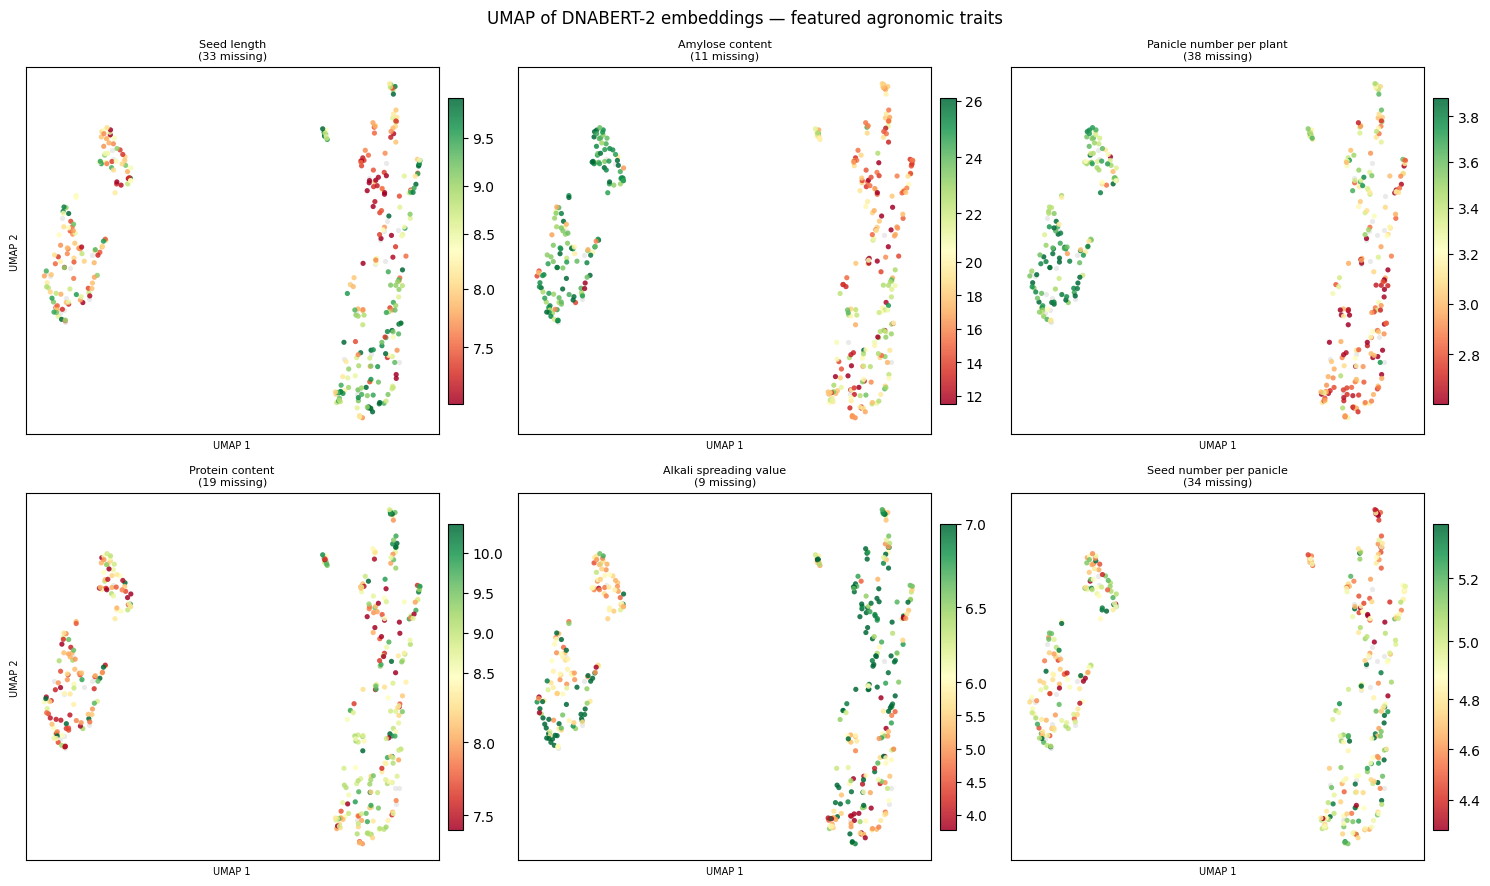

In [15]:
FEATURED = [
    "Seed length",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Alkali spreading value",
    "Seed number per panicle",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, trait in enumerate(FEATURED):
    plot_umap_trait(axes[i], trait, coords, pheno_matched, TRAIT_COLS)
    axes[i].set_xlabel("UMAP 1", fontsize=7)
    if i % 3 == 0:
        axes[i].set_ylabel("UMAP 2", fontsize=7)

plt.suptitle("UMAP of DNABERT-2 embeddings — featured agronomic traits", fontsize=12)
plt.tight_layout()
plt.show()

### 4a. Population axis reference

Colour by PC1 score (the dominant axis, ~41% of variance) so you can compare
how much each trait's gradient aligns with the population structure.

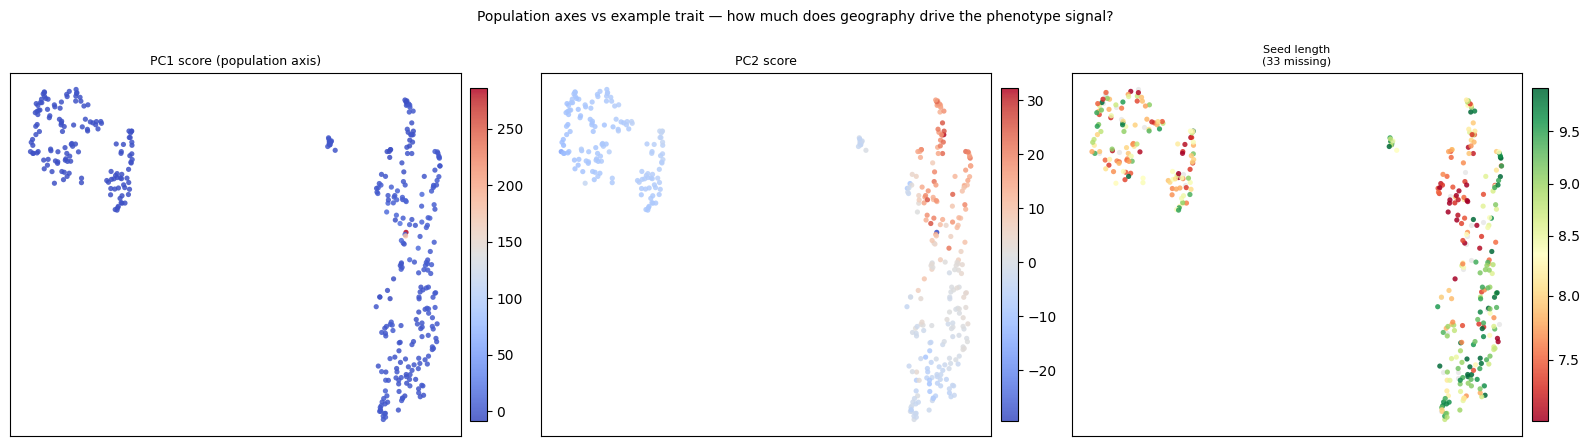

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PC1 score
sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=X_svd[:, 0],
                       cmap="coolwarm", s=14, alpha=0.85, linewidths=0)
axes[0].set_title("PC1 score (population axis)", fontsize=9)
plt.colorbar(sc0, ax=axes[0], fraction=0.035, pad=0.02)
axes[0].set_xticks([]); axes[0].set_yticks([])

# PC2 score
sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=X_svd[:, 1],
                       cmap="coolwarm", s=14, alpha=0.85, linewidths=0)
axes[1].set_title("PC2 score", fontsize=9)
plt.colorbar(sc1, ax=axes[1], fraction=0.035, pad=0.02)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Seed length for comparison
plot_umap_trait(axes[2], "Seed length", coords, pheno_matched, TRAIT_COLS)

plt.suptitle("Population axes vs example trait — how much does geography drive the phenotype signal?",
             fontsize=10)
plt.tight_layout()
plt.show()

## 5. Full grid — all traits

Every trait in a single figure. Resize or scroll to inspect individual panels.

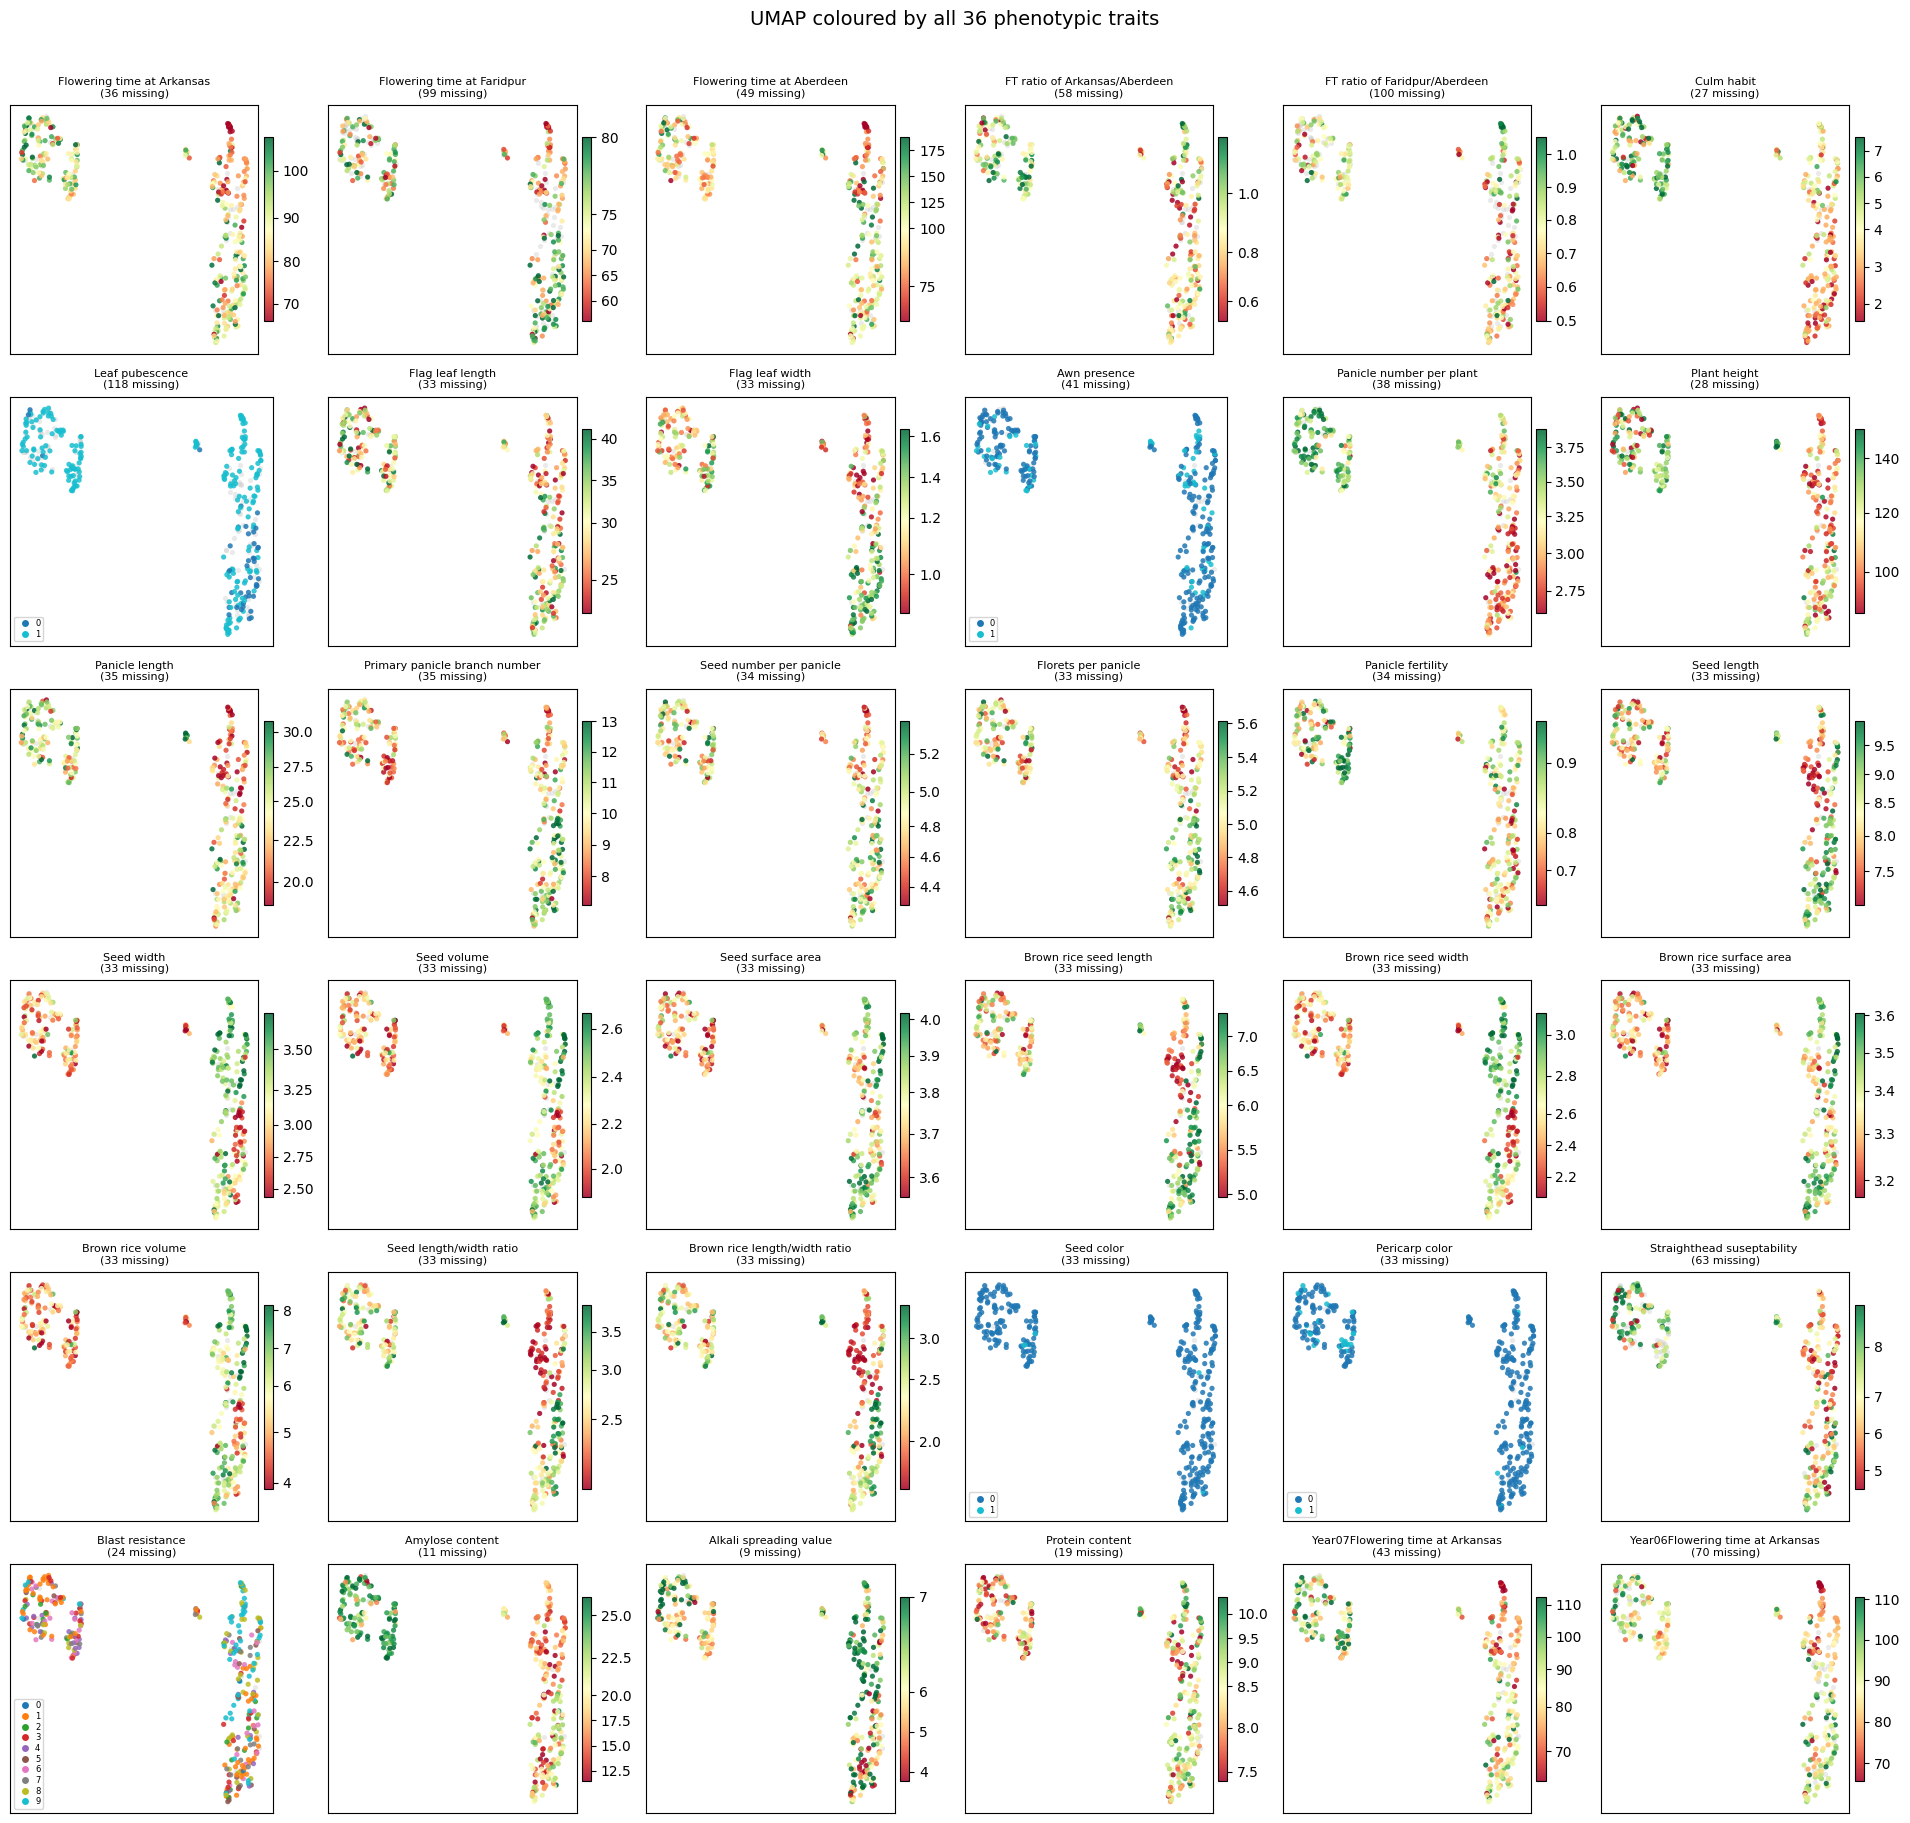

In [8]:
N_TRAITS = len(TRAIT_COLS)
NCOLS    = 6
NROWS    = (N_TRAITS + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 3.2, NROWS * 3.0))
axes = axes.ravel()

for i, trait in enumerate(TRAIT_COLS):
    plot_umap_trait(axes[i], trait, coords, pheno_matched, TRAIT_COLS)

# Hide any unused subplots
for j in range(N_TRAITS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"UMAP coloured by all {N_TRAITS} phenotypic traits", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Single-trait deep-dive

Change `TRAIT` to inspect any trait at full size.

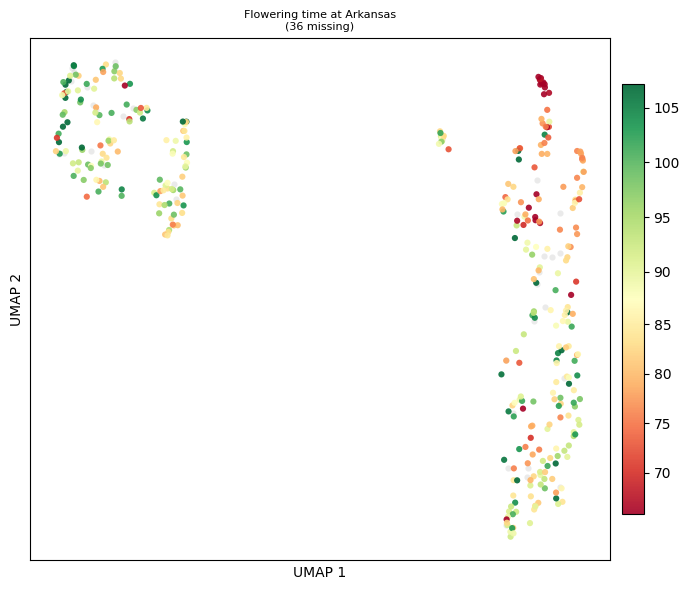

Available traits:
  Flowering time at Arkansas
  Flowering time at Faridpur
  Flowering time at Aberdeen
  FT ratio of Arkansas/Aberdeen
  FT ratio of Faridpur/Aberdeen
  Culm habit
  Leaf pubescence
  Flag leaf length
  Flag leaf width
  Awn presence
  Panicle number per plant
  Plant height
  Panicle length
  Primary panicle branch number
  Seed number per panicle
  Florets per panicle
  Panicle fertility
  Seed length
  Seed width
  Seed volume
  Seed surface area
  Brown rice seed length
  Brown rice seed width
  Brown rice surface area
  Brown rice volume
  Seed length/width ratio
  Brown rice length/width ratio
  Seed color 
  Pericarp color
  Straighthead suseptability 
  Blast resistance
  Amylose content
  Alkali spreading value
  Protein content
  Year07Flowering time at Arkansas
  Year06Flowering time at Arkansas


In [9]:
TRAIT = "Flowering time at Arkansas"   # ← change me

fig, ax = plt.subplots(figsize=(7, 6))
plot_umap_trait(ax, TRAIT, coords, pheno_matched, TRAIT_COLS, s=20, alpha=0.9)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

print(f"Available traits:\n" + "\n".join(f"  {t}" for t in TRAIT_COLS))